In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

INTERIM_DIR = Path("../data/interim")

df = pd.read_parquet(INTERIM_DIR / "retail_clean.parquet")

# fix Customer ID dtype (float artifact from earlier NaN handling)
df["Customer ID"] = df["Customer ID"].astype(int).astype(str)

print(df.shape)
df.head()

(824293, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False


In [6]:
purchases = df[~df["is_cancellation"]].copy()
cancellations = df[df["is_cancellation"]].copy()

print("Purchase rows:", len(purchases))
print("Cancellation rows:", len(cancellations))

Purchase rows: 805549
Cancellation rows: 18744


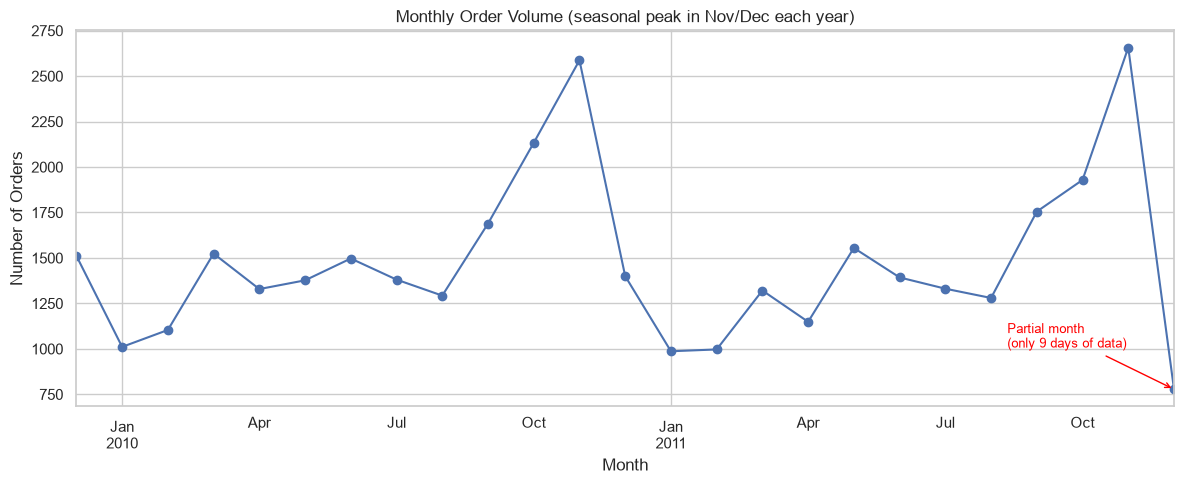

In [11]:
monthly_orders = (
    purchases
    .drop_duplicates(subset="Invoice")  # one row per invoice for order-level counting
    .set_index("InvoiceDate")
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind="line", marker="o")

# annotate the partial month
plt.axvspan(monthly_orders.index[-1] - pd.Timedelta(days=15), monthly_orders.index[-1] + pd.Timedelta(days=15),
            color="red", alpha=0.1)
plt.annotate("Partial month\n(only 9 days of data)",
             xy=(monthly_orders.index[-1], monthly_orders.iloc[-1]),
             xytext=(-120, 30), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red", fontsize=9)

plt.title("Monthly Order Volume (seasonal peak in Nov/Dec each year)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [9]:
orders_per_customer = (
    purchases.groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index(name="n_orders")
)

orders_per_customer["n_orders"].describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: n_orders, dtype: float64

In [10]:
one_time = (orders_per_customer["n_orders"] == 1).sum()
repeat = (orders_per_customer["n_orders"] > 1).sum()
total = len(orders_per_customer)

print(f"One-time buyers: {one_time} ({one_time/total:.1%})")
print(f"Repeat buyers:   {repeat} ({repeat/total:.1%})")

One-time buyers: 1623 (27.6%)
Repeat buyers:   4255 (72.4%)


In [12]:
reference_date = df["InvoiceDate"].max()
print("Reference date for recency calculations:", reference_date)

Reference date for recency calculations: 2011-12-09 12:50:00


In [13]:
# get one row per invoice (order-level), sorted by customer and date
order_dates = (
    purchases
    .drop_duplicates(subset="Invoice")
    [["Customer ID", "InvoiceDate"]]
    .sort_values(["Customer ID", "InvoiceDate"])
)

# compute days since previous order, within each customer
order_dates["days_since_prev_order"] = (
    order_dates.groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.days
)

# drop the first order per customer (no previous order to compare to)
gaps = order_dates["days_since_prev_order"].dropna()

gaps.describe()

count    31091.000000
mean        51.239426
std         75.754392
min          0.000000
25%          6.000000
50%         24.000000
75%         61.000000
max        714.000000
Name: days_since_prev_order, dtype: float64

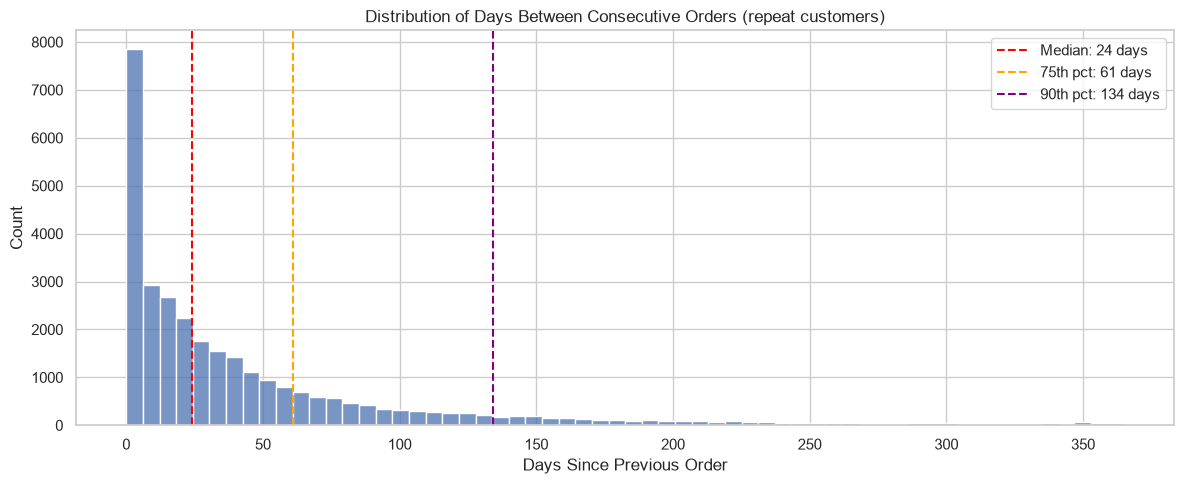

In [14]:
plt.figure(figsize=(12, 5))
sns.histplot(gaps[gaps <= 365], bins=60, kde=False)  # cap at 1 year for readability
plt.axvline(gaps.median(), color="red", linestyle="--", label=f"Median: {gaps.median():.0f} days")
plt.axvline(gaps.quantile(0.75), color="orange", linestyle="--", label=f"75th pct: {gaps.quantile(0.75):.0f} days")
plt.axvline(gaps.quantile(0.90), color="purple", linestyle="--", label=f"90th pct: {gaps.quantile(0.90):.0f} days")
plt.title("Distribution of Days Between Consecutive Orders (repeat customers)")
plt.xlabel("Days Since Previous Order")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
for pct in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95]:
    print(f"{int(pct*100)}th percentile: {gaps.quantile(pct):.0f} days")

50th percentile: 24 days
60th percentile: 35 days
70th percentile: 50 days
75th percentile: 61 days
80th percentile: 76 days
90th percentile: 134 days
95th percentile: 206 days


In [20]:
reference_date = df["InvoiceDate"].max()
CHURN_WINDOW_DAYS = 75

# recency per customer: days since their most recent purchase
customer_recency = (
    purchases.groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index(name="last_purchase_date")
)

customer_recency["recency_days"] = (reference_date - customer_recency["last_purchase_date"]).dt.days
customer_recency["is_churned"] = customer_recency["recency_days"] > CHURN_WINDOW_DAYS

customer_recency["is_churned"].value_counts(normalize=True)

is_churned
True     0.53998
False    0.46002
Name: proportion, dtype: float64

In [28]:
rfm = (
    purchases.groupby("Customer ID")
    .agg(
        last_purchase_date=("InvoiceDate", "max"),
        frequency=("Invoice", "nunique"),
        monetary=("Price", lambda x: (x * purchases.loc[x.index, "Quantity"]).sum()),
    )
    .reset_index()
)

rfm["recency_days"] = (reference_date - rfm["last_purchase_date"]).dt.days

rfm.describe()

,last_purchase_date,frequency,monetary,recency_days
count,5878,5878.000000,5878.000000,5878.000000
mean,2011-05-22 16:19:59.469207,6.289384,3018.616737,200.331916
min,2009-12-01 09:55:00,1.000000,2.950000,0.000000
25%,2010-11-25 10:24:45,1.000000,348.762500,25.000000
50%,2011-09-05 11:59:00,3.000000,898.915000,95.000000
75%,2011-11-14 11:31:15,7.000000,2307.090000,379.000000
max,2011-12-09 12:50:00,398.000000,608821.650000,738.000000
std,NaN,13.009406,14737.731040,209.338707


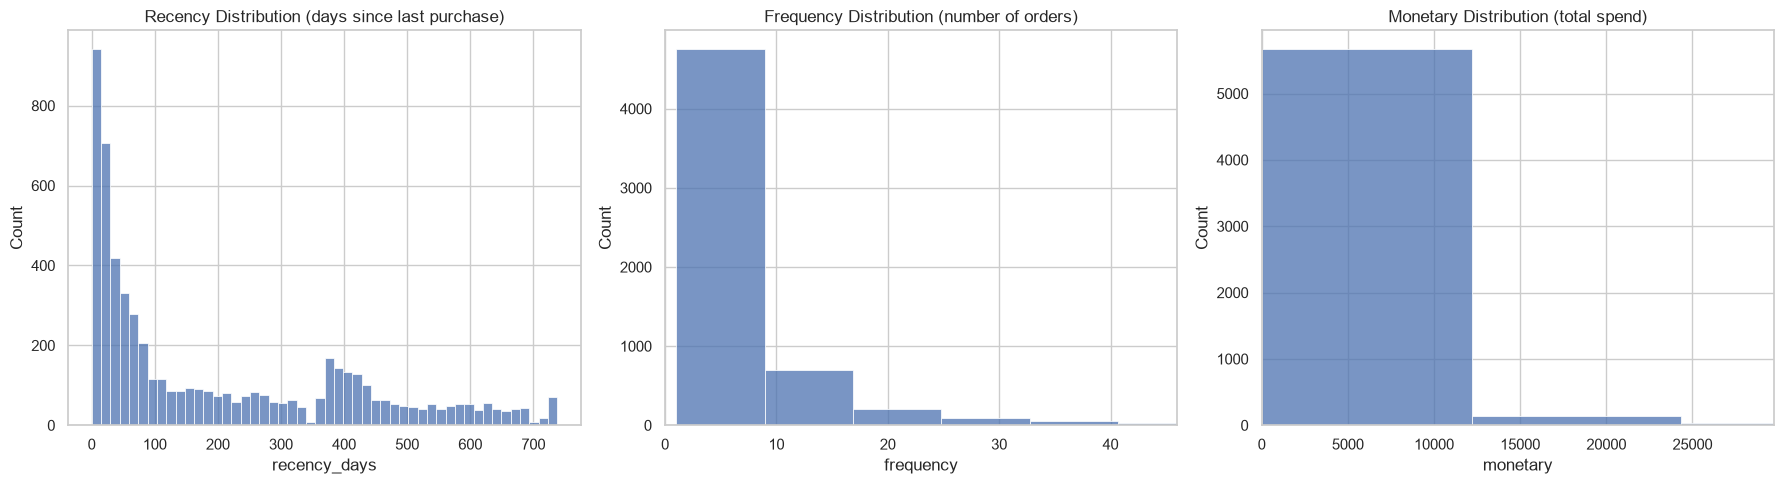

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["recency_days"], bins=50, ax=axes[0])
axes[0].set_title("Recency Distribution (days since last purchase)")

sns.histplot(rfm["frequency"], bins=50, ax=axes[1])
axes[1].set_title("Frequency Distribution (number of orders)")
axes[1].set_xlim(0, rfm["frequency"].quantile(0.99))  # trim extreme outliers for readability

sns.histplot(rfm["monetary"], bins=50, ax=axes[2])
axes[2].set_title("Monetary Distribution (total spend)")
axes[2].set_xlim(0, rfm["monetary"].quantile(0.99))

plt.tight_layout()
plt.show()

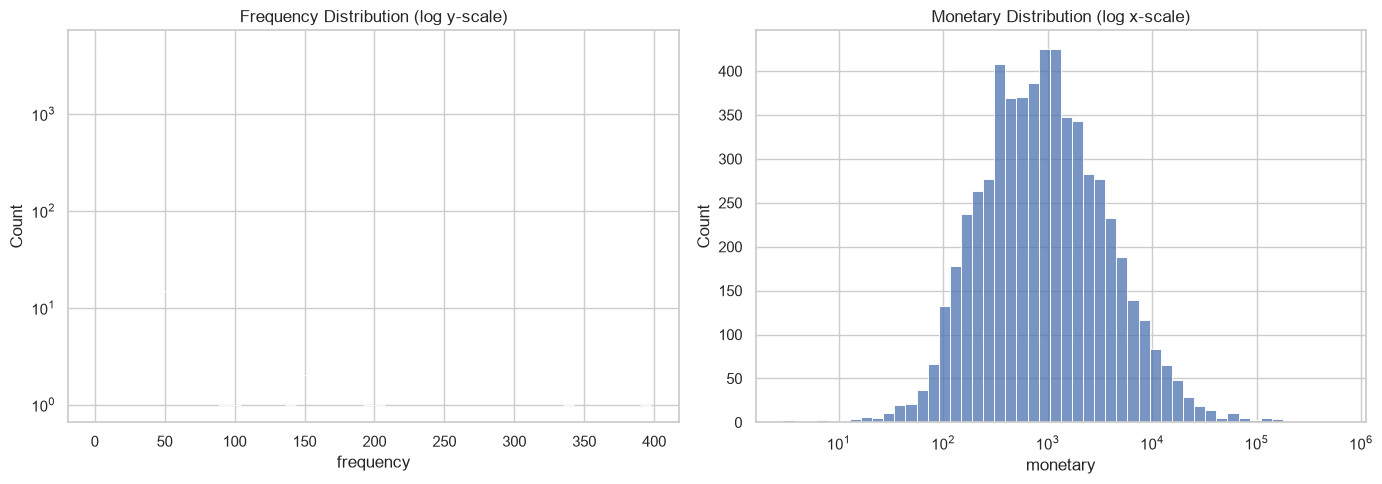

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(rfm["frequency"], bins=50, log_scale=(False, True), ax=axes[0])
axes[0].set_title("Frequency Distribution (log y-scale)")

sns.histplot(rfm["monetary"][rfm["monetary"] > 0], bins=50, log_scale=True, ax=axes[1])
axes[1].set_title("Monetary Distribution (log x-scale)")

plt.tight_layout()
plt.show()

In [25]:
# first purchase month per customer (acquisition cohort)
order_dates = purchases.drop_duplicates(subset="Invoice")[["Customer ID", "InvoiceDate"]]

order_dates["order_month"] = order_dates["InvoiceDate"].dt.to_period("M")
cohort_month = order_dates.groupby("Customer ID")["order_month"].min().reset_index(name="cohort_month")

order_dates = order_dates.merge(cohort_month, on="Customer ID")

# period number = how many months after acquisition this order occurred
order_dates["period_number"] = (
    (order_dates["order_month"].dt.year - order_dates["cohort_month"].dt.year) * 12
    + (order_dates["order_month"].dt.month - order_dates["cohort_month"].dt.month)
)

# count unique customers active in each cohort x period_number
cohort_data = (
    order_dates.groupby(["cohort_month", "period_number"])["Customer ID"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(index="cohort_month", columns="period_number", values="Customer ID")

# convert to retention %, relative to cohort's period 0 (initial size)
cohort_size = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_matrix.round(3)

period_number,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN
2010-05,1.0,0.157,0.169,0.173,0.177,0.256,0.213,0.126,0.059,0.083,...,0.126,0.138,0.165,0.154,0.047,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174,0.189,0.204,0.230,0.285,0.126,0.089,0.081,0.119,...,0.122,0.133,0.204,0.052,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.156,0.183,0.296,0.290,0.140,0.113,0.145,0.145,0.113,...,0.172,0.237,0.081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.204,0.296,0.321,0.173,0.117,0.099,0.123,0.136,0.130,...,0.198,0.068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


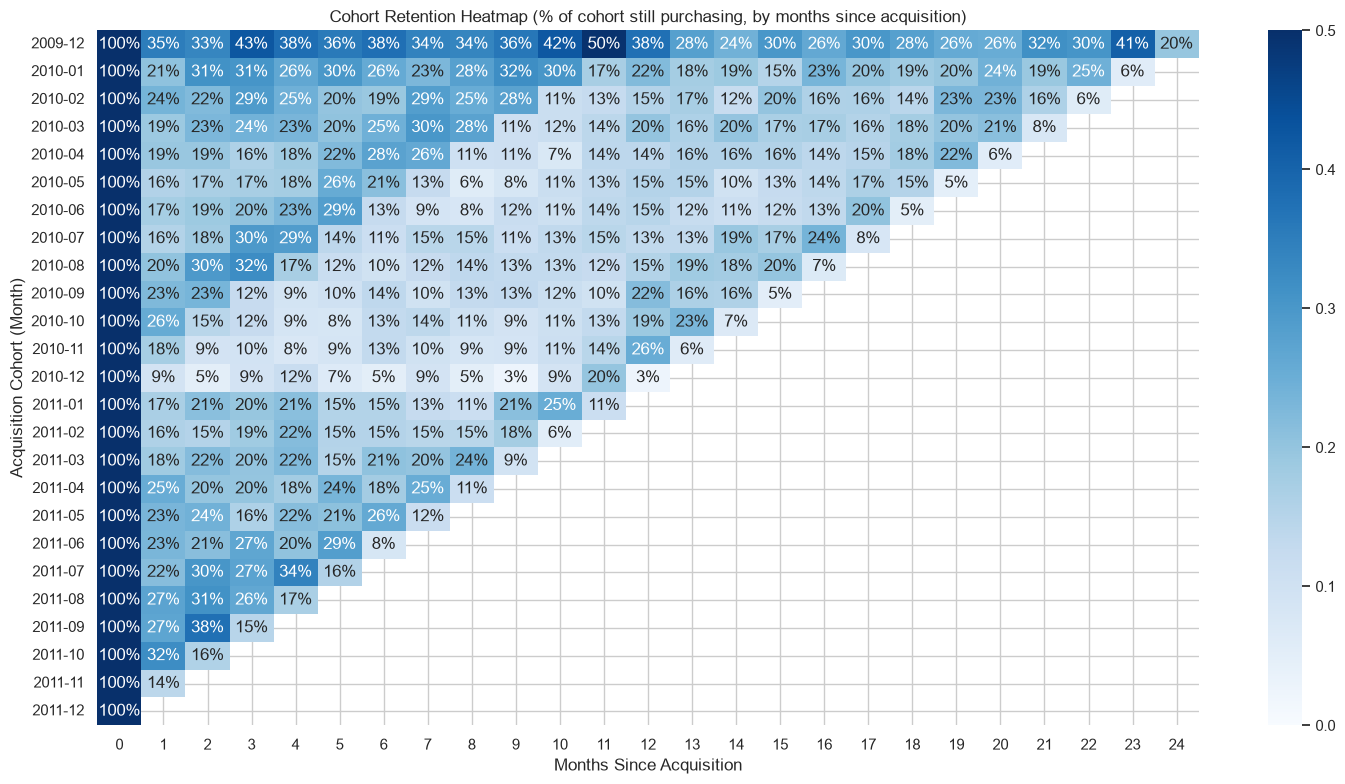

In [26]:
plt.figure(figsize=(15, 8))
sns.heatmap(retention_matrix, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=0.5)
plt.title("Cohort Retention Heatmap (% of cohort still purchasing, by months since acquisition)")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Acquisition Cohort (Month)")
plt.tight_layout()
plt.show()

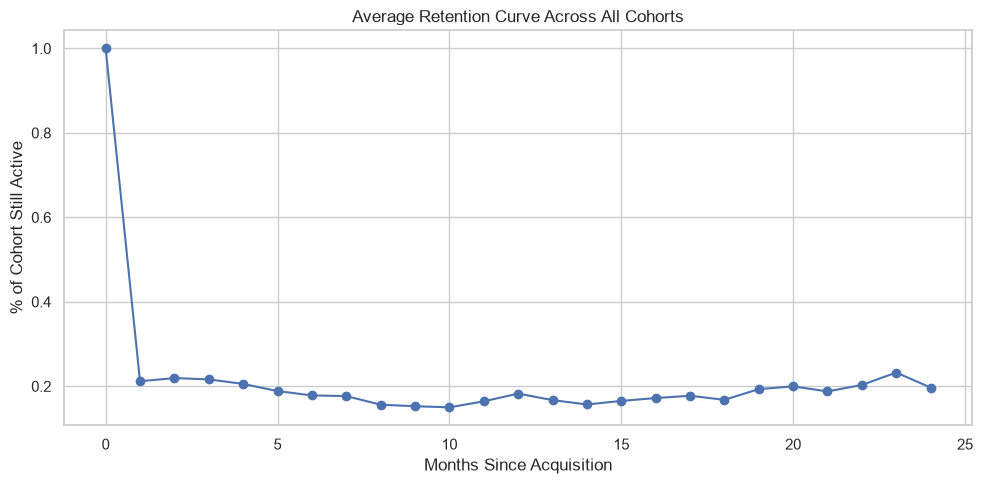

In [27]:
avg_retention = retention_matrix.mean(axis=0)

plt.figure(figsize=(10, 5))
avg_retention.plot(kind="line", marker="o")
plt.title("Average Retention Curve Across All Cohorts")
plt.xlabel("Months Since Acquisition")
plt.ylabel("% of Cohort Still Active")
plt.tight_layout()
plt.show()